# Compare position-matrix sources

Compares position-matrix **sources** on one Wannierization, along a generic line. Unlike `compare_trial_curvature.ipynb` (which compares two different Wannierizations, trial03 vs trial04, both built with the `mmn` source), this compares three ways of getting `A(R)` for the *same* Wannierization -- SrTiO3 Ti_Q_2A trial04 (38 WF, occupied-only):

- **`mmn`** -- the established-correct reference: `.chk` (this trial's own gauge) + `.mmn` borrowed from trial03 (same NSCF).
- **`rdat_ndegen_applied`** -- Jae-Mo Lihm's wannier90.x fix: raw `_r.dat`/`_hr.dat`, no `.mmn`, no Python remap.
- **`rfull`** -- our own postw90.x patch (`write_aa_r`): `_r_full.dat`, generated locally, also using the borrowed `.mmn`.

All three share this trial's own `.chk` for H(R)/gauge, so the comparison is position-matrix-source-only. See `notes/jaemo-wannier90-fork.md` for the full numeric writeup: `rdat_ndegen_applied` and `rfull` agree with each other to ~1e-8, while both differ from `mmn` by the already-documented mmn-vs-rfull discretisation-family gap.

Set `RUN_COMPUTATION = False` to load the last saved run from `results/position_matrix_sources/`.

In [1]:
import csv
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "validation").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from validation._paths import RESULTS, STO_TI_Q_2A_RUN
from validation._paths import DATA
import validation.symmetry.compare_trial_curvature_lib as ctc

N_OCC = 38
COMPONENTS = ctc.COMPONENTS

## Config

In [2]:
RUN_COMPUTATION = False  # True: rebuild all three sources and recompute. False: load results/position_matrix_sources/.
POINTS = 201
DIRECTORY = DATA / "SrTiO3/Ti_Q_2A/output/188914bc889/trial_04_Sr_sp_Ti_p_O_sp/proj_gauge/191583bc889"
MMN_DIRECTORY = DATA / "SrTiO3/Ti_Q_2A/output/188914bc889/trial_03_Sr_sp_Ti_pd_O_sp/proj_gauge/191509bc889"
OUTPUT_DIR = RESULTS / "position_matrix_sources"
CACHE_DIR = OUTPUT_DIR

SOURCES = {
    "mmn": {
        "source": "mmn",
        "label": "mmn_pair (established correct: .chk + borrowed .mmn)",
        "color": "0.4",
    },
    "rdat_ndegen_applied": {
        "source": "rdat_ndegen_applied",
        "label": "Jae-Mo: _r.dat/_hr.dat (write_ndegen_applied, no .mmn)",
        "color": "C3",
    },
    "rfull": {
        "source": "rfull",
        "label": "ours: postw90 _r_full.dat (write_aa_r, local)",
        "color": "C0",
    },
}

# Passed explicitly to ctc.build_trial below, rather than monkeypatching
# ctc.TRIALS -- keeps this notebook's config local to this notebook's kernel.
TRIALS = {
    "mmn": {"directory": DIRECTORY, "mmn_directory": MMN_DIRECTORY, "source": "mmn",
             "cache": CACHE_DIR / "AA_mmn.npz"},
    "rdat_ndegen_applied": {"directory": DIRECTORY, "source": "rdat_ndegen_applied"},
    "rfull": {"directory": DIRECTORY, "source": "rfull"},
}

## Build all three sources and evaluate on the generic line

`results[key]["curvature"]` is the full traced-occupied curvature tensor for that source -- inspect any entry directly.

In [3]:
if RUN_COMPUTATION:
    t = np.linspace(0.0, 1.0, POINTS)
    kpoints = np.column_stack((t, np.full_like(t, 0.30), np.full_like(t, 0.15)))

    results = {}
    for key in ("mmn", "rdat_ndegen_applied", "rfull"):
        print(f"building {key}: {SOURCES[key]['label']}")
        model, pos = ctc.build_trial(key, TRIALS)
        results[key] = ctc.evaluate_trial(model, pos, kpoints)
        del model, pos

building mmn: mmn_pair (established correct: .chk + borrowed .mmn)


    H(R) orbital-dependent mapping (min |R + tau_right - tau_left|): 729 -> 729 R-vectors, 0.000% of the weight moved outside the input set


mmn: 38 WFs, 38 occupied; source=mmn; A(R) Hermiticity=0.000e+00, outside-H(R) weight=0.000e+00


building rdat_ndegen_applied: Jae-Mo: _r.dat/_hr.dat (write_ndegen_applied, no .mmn)


rdat_ndegen_applied: 38 WFs, 38 occupied; source=rdat_ndegen_applied; reads _r.dat/_hr.dat (write_ndegen_applied); diagnostics={'ndegen_applied_hermiticity_max': 1.0000000000699553e-11, 'ndegen_applied_hermiticity_relative': 1.0574496324909055e-12, 'centres_max_error': 4.999999969612645e-08, 'zero_H_blocks_added': 0}


building rfull: ours: postw90 _r_full.dat (write_aa_r, local)


rfull: 38 WFs, 38 occupied; source=rfull; reads _r_full.dat; diagnostics={'header': 'written by postw90 on 16Sep2026 at 00:18:27 ; transl_inv_full=T; use_ws_distance=T; effective_ws_weights=T', 'num_wann': 38, 'num_R': 729, 'transl_inv_full': True, 'use_ws_distance': True, 'effective_ws_weights': True, 'n_R_pos': 729, 'zero_H_blocks_added': 0, 'pair_hermiticity_max': 7.754666067442654e-15, 'pair_hermiticity_relative': 8.717244207526749e-14, 'centres_max_error': 4.9426138737374e-09}


## Metrics: each source against `mmn`, and `rdat_ndegen_applied` against `rfull`

In [4]:
if RUN_COMPUTATION:
    left = results["mmn"]["trace"]
    metrics: dict[str, object] = {"n_occupied": N_OCC, "sources": {}}
    for key in ("rdat_ndegen_applied", "rfull"):
        right = results[key]["trace"]
        difference = right - left
        metrics["sources"][key] = {
            "max_abs_energy_difference_eV": float(
                np.max(np.abs(results[key]["energies"] - results["mmn"]["energies"]))
            ),
            "components": {
                name: {
                    "max_abs_difference_A2": float(np.max(np.abs(difference[:, i]))),
                    "relative_l2_difference": float(
                        np.linalg.norm(difference[:, i]) / ref
                        if (ref := np.linalg.norm(left[:, i])) > 0
                        else np.nan
                    ),
                }
                for i, (_, _, name) in enumerate(COMPONENTS)
            },
        }
    right = results["rfull"]["trace"]
    left_j = results["rdat_ndegen_applied"]["trace"]
    difference = right - left_j
    metrics["rdat_ndegen_applied_vs_rfull"] = {
        "max_abs_energy_difference_eV": float(
            np.max(np.abs(results["rfull"]["energies"] - results["rdat_ndegen_applied"]["energies"]))
        ),
        "components": {
            name: {
                "relative_l2_difference": float(
                    np.linalg.norm(difference[:, i]) / ref
                    if (ref := np.linalg.norm(left_j[:, i])) > 0
                    else np.nan
                ),
            }
            for i, (_, _, name) in enumerate(COMPONENTS)
        },
    }
    print(json.dumps(metrics, indent=2, sort_keys=True))

{
  "n_occupied": 38,
  "rdat_ndegen_applied_vs_rfull": {
    "components": {
      "xy": {
        "relative_l2_difference": 5.460532507868832e-09
      },
      "yz": {
        "relative_l2_difference": 1.1481778049396617e-08
      },
      "zx": {
        "relative_l2_difference": 1.0168195568810669e-08
      }
    },
    "max_abs_energy_difference_eV": 0.0
  },
  "sources": {
    "rdat_ndegen_applied": {
      "components": {
        "xy": {
          "max_abs_difference_A2": 0.01353336917208077,
          "relative_l2_difference": 0.501539242448461
        },
        "yz": {
          "max_abs_difference_A2": 0.0030695338448279985,
          "relative_l2_difference": 0.0020594176513933607
        },
        "zx": {
          "max_abs_difference_A2": 0.003028552166818299,
          "relative_l2_difference": 0.0023000864313413123
        }
      },
      "max_abs_energy_difference_eV": 0.0
    },
    "rfull": {
      "components": {
        "xy": {
          "max_abs_difference_A2":

## Save

In [5]:
if RUN_COMPUTATION:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    csv_path = OUTPUT_DIR / "generic_line_trace_curvature.csv"
    npz_path = OUTPUT_DIR / "generic_line_trace_curvature.npz"
    json_path = OUTPUT_DIR / "generic_line_trace_curvature_summary.json"

    with csv_path.open("w", newline="") as handle:
        writer = csv.writer(handle)
        header = ["t", "kx_red", "ky_red", "kz_red"]
        for _, _, component in COMPONENTS:
            for key in SOURCES:
                header.append(f"{key}_trace_omega_{component}_A2")
        writer.writerow(header)
        for point_index in range(len(t)):
            row = [t[point_index], *kpoints[point_index]]
            for component_index in range(len(COMPONENTS)):
                for key in SOURCES:
                    row.append(results[key]["trace"][point_index, component_index])
            writer.writerow(row)

    np.savez_compressed(
        npz_path,
        t=t,
        kpoints_reduced=kpoints,
        components=np.array([name for _, _, name in COMPONENTS]),
        **{f"{key}_trace": results[key]["trace"] for key in SOURCES},
        **{f"{key}_occupied_energies": results[key]["energies"] for key in SOURCES},
    )
    json_path.write_text(json.dumps(metrics, indent=2, sort_keys=True) + "\n")
    print(f"saved {csv_path}")
    print(f"saved {npz_path}")
    print(f"saved {json_path}")

saved /Users/treycole/Repos/axion-phonon/validation/results/position_matrix_sources/generic_line_trace_curvature.csv
saved /Users/treycole/Repos/axion-phonon/validation/results/position_matrix_sources/generic_line_trace_curvature.npz
saved /Users/treycole/Repos/axion-phonon/validation/results/position_matrix_sources/generic_line_trace_curvature_summary.json


## Load previously saved results (skip if you just computed above)

In [6]:
if not RUN_COMPUTATION:
    data = np.load(OUTPUT_DIR / "generic_line_trace_curvature.npz")
    t = data["t"]
    results = {key: {"trace": data[f"{key}_trace"], "energies": data[f"{key}_occupied_energies"]} for key in SOURCES}
    metrics = json.loads((OUTPUT_DIR / "generic_line_trace_curvature_summary.json").read_text())
    print(json.dumps(metrics, indent=2, sort_keys=True))

## Plot

saved /Users/treycole/Repos/axion-phonon/validation/results/position_matrix_sources/generic_line_trace_curvature.png


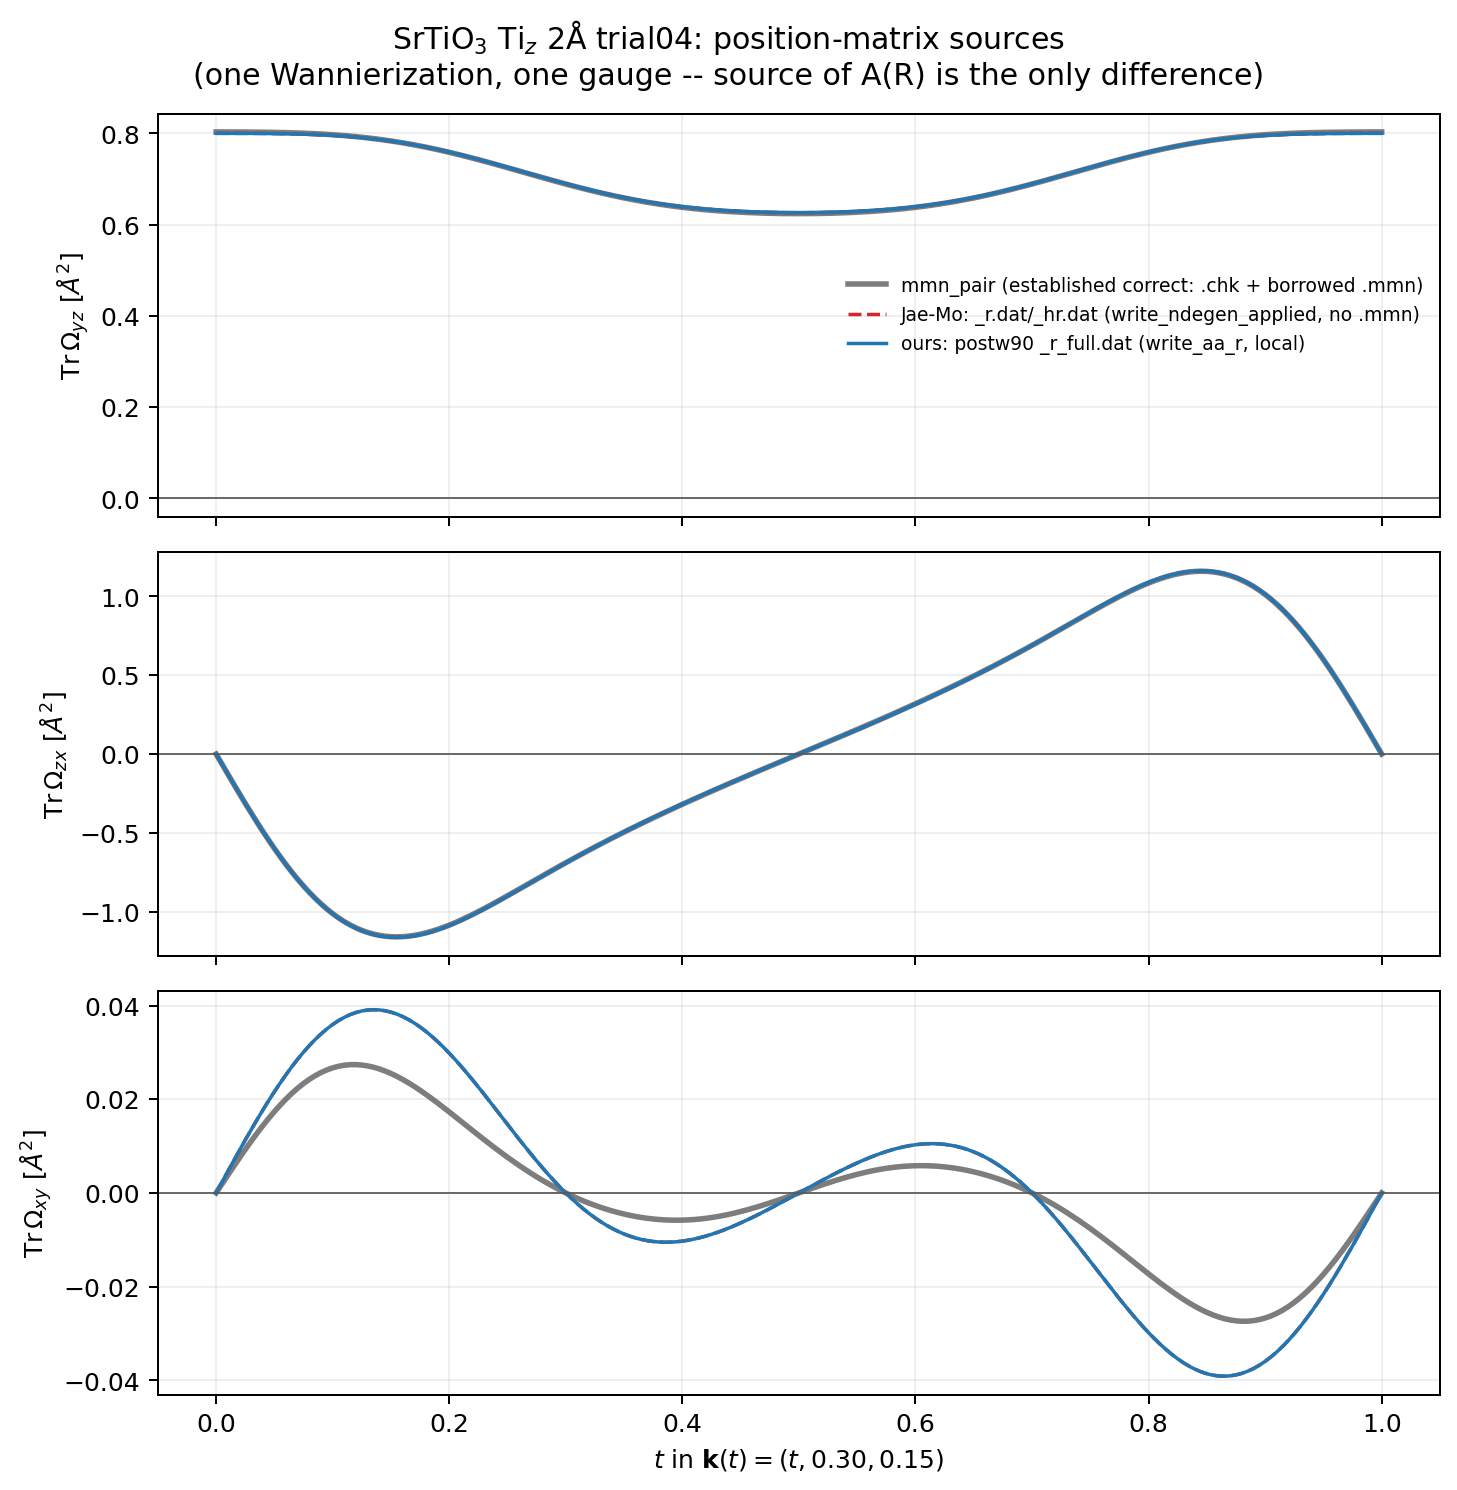

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(8.2, 8.4), sharex=True, dpi=180)
for component_index, (i, j, component) in enumerate(COMPONENTS):
    axis = axes[component_index]
    for key, setup in SOURCES.items():
        axis.plot(
            t,
            results[key]["trace"][:, component_index],
            color=setup["color"],
            linewidth=2.2 if key == "mmn" else 1.4,
            linestyle="-" if key != "rdat_ndegen_applied" else "--",
            alpha=0.85 if key == "mmn" else 1.0,
            label=setup["label"],
        )
    axis.axhline(0.0, color="0.35", linewidth=0.7)
    axis.set_ylabel(rf"$\mathrm{{Tr}}\,\Omega_{{{component}}}$ [$\AA^2$]")
    axis.grid(alpha=0.2)
    if component_index == 0:
        axis.legend(frameon=False, fontsize=7.5)
axes[-1].set_xlabel(r"$t$ in $\mathbf{k}(t)=(t,0.30,0.15)$")
fig.suptitle(
    r"SrTiO$_3$ Ti$_z$ 2$\mathrm{\AA}$ trial04: position-matrix sources"
    "\n(one Wannierization, one gauge -- source of A(R) is the only difference)"
)
fig.tight_layout()
if RUN_COMPUTATION:
    plot_path = OUTPUT_DIR / "generic_line_trace_curvature.png"
    fig.savefig(plot_path, bbox_inches="tight")
    print(f"saved {plot_path}")
plt.show()